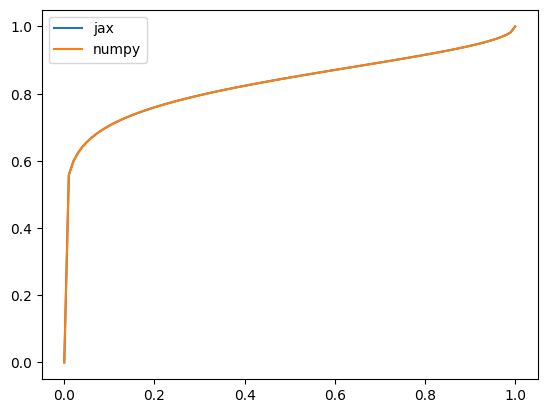

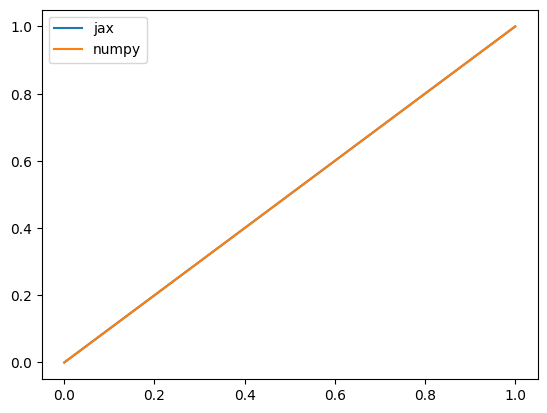

In [3]:
# enable 64-bit precision
import jax
import jax.numpy as jnp
from jax.scipy.special import betainc
from scipy.special import betainc as betainc_np
from scipy.special import betaincinv as betaincinv_np

from probjax.utils.stats import betaincinv

#
# jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

a = 0.1
b = 0.5
p = jnp.linspace(0, 1, 100)

y = betainc(a, b, p)
p_rec = betaincinv(a, b, y)

y_np = betainc_np(a, b, p)
p_rec_np = betaincinv_np(a, b, y_np)

import matplotlib.pyplot as plt

plt.plot(p, y, label='jax')
plt.plot(p, y_np, label='numpy')
plt.legend()
plt.show()

plt.plot(p, p_rec, label='jax')
plt.plot(p, p_rec_np, label='numpy')

plt.legend()


In [4]:
%%timeit
betaincinv(a, b, y)

621 μs ± 8.54 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [18]:
%%timeit

p_rec_np = betaincinv_np(a, b, y_np)

8.72 μs ± 160 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [10]:
import jax.numpy as jnp
from jax import grad
from jax.scipy.special import erf, erfinv


# Normal CDF and inverse CDF using erfc
def normal_cdf(x):
    return 0.5 * (1 + erf(x / jnp.sqrt(2)))

def normal_inv_cdf(u):
    return jnp.sqrt(2) * erfinv(2 * (1 - u))

# Normal Asymptotic Approximation (QN)
def Q_N(u, n, p):
    q = 1 - p
    npq_sqrt = jnp.sqrt(n * p * q)
    w = normal_inv_cdf(u)


    # First-order Cornish-Fisher expansion
    QN0 = n * p + npq_sqrt * w + (2 + 2 * p + (q - p) * w ** 2) / 6

    # Second-order correction
    QN1 = QN0 + ((-2 + 14 * p * q) * w + (-1 - 2 * p * q) * w ** 3) / (72 * npq_sqrt)

    # Third-order correction
    QN2 = QN1 + (p - q) * (2 + p * q) * (16 - 7 * w ** 2 - 3 * w ** 4) / (1620 * n * p * q)

    return QN2

# GST Asymptotic Approximation (QT)
def hp(ξ, p):
    # Ensure numerical stability with jnp.maximum
    log_term1 = jnp.log(p / ξ + 1e-8)
    log_term2 = jnp.log((1 - p) / (1 - ξ + 1e-8))
    return jnp.sqrt(jnp.maximum(-2 * (ξ * log_term1 + (1 - ξ) * log_term2), 0)).sum()

def hp_inv(η, p):
    # Newton iteration to find ξ from η
    ξ = p
    for _ in range(5):
        f = hp(ξ, p) - η
        df_dξ = grad(hp)(ξ, p)
        ξ -= f / (df_dξ + 1e-8)  # Adding a small value to avoid division by zero
        ξ = jnp.clip(ξ, 1e-8, 1 - 1e-8)  # Clipping to avoid domain errors
    return ξ

def Q_T(u, n, p):
    q = 1 - p
    ν = n + 1
    w = normal_inv_cdf(u)
    η0 = -w / jnp.sqrt(ν)


    ξ0 = hp_inv(η0, p)
    x = ν * ξ0


    # Correction term
    fp = jnp.maximum(ξ0 * (1 - ξ0) * η0 / (p - ξ0 + 1e-8), 1e-8)  # Avoid division by zero
    log_fp = jnp.log(fp) / η0
    log_correction = -η0 / jnp.maximum(jnp.log((1 - ξ0) / ξ0 * p / (1 - p) + 1e-8), 1e-8)
    gp = log_fp * log_correction

    return x + gp


# Inverse of the incomplete beta function using the approximations
def betaincinv(a, b, x):
    n = a + b - 1
    u = x
    p = a / n

    # Choose the appropriate approximation based on |Φ⁻¹(p)|
    w = normal_inv_cdf(p)

    return jnp.where(jnp.abs(w) <= 3, Q_N(u, n, p) / n, Q_T(u, n, p) / n)

# Example Usage
a = 100
b = 1
n = a + b - 1
u = jnp.linspace(0, 1, 1000) / n
p = a / n

print(n, u, p)


t1 = Q_N(u, n, p)
t2 = Q_T(u, n, p)

# Compute the inverse incomplete beta function
betainv_result = betaincinv(100, 1000, jnp.linspace(0, 1, 1000))
_ = plt.plot(p, betainv_result)

100 [0.0000000e+00 1.0010010e-05 2.0020019e-05 3.0030031e-05 4.0040039e-05
 5.0050046e-05 6.0060062e-05 7.0070069e-05 8.0080077e-05 9.0090092e-05
 1.0010009e-04 1.1011011e-04 1.2012012e-04 1.3013012e-04 1.4014014e-04
 1.5015014e-04 1.6016015e-04 1.7017015e-04 1.8018018e-04 1.9019019e-04
 2.0020019e-04 2.1021022e-04 2.2022022e-04 2.3023022e-04 2.4024025e-04
 2.5025025e-04 2.6026025e-04 2.7027025e-04 2.8028028e-04 2.9029028e-04
 3.0030028e-04 3.1031031e-04 3.2032031e-04 3.3033031e-04 3.4034031e-04
 3.5035031e-04 3.6036037e-04 3.7037037e-04 3.8038037e-04 3.9039037e-04
 4.0040037e-04 4.1041037e-04 4.2042043e-04 4.3043043e-04 4.4044043e-04
 4.5045043e-04 4.6046043e-04 4.7047043e-04 4.8048049e-04 4.9049046e-04
 5.0050049e-04 5.1051046e-04 5.2052049e-04 5.3053052e-04 5.4054050e-04
 5.5055053e-04 5.6056055e-04 5.7057053e-04 5.8058056e-04 5.9059059e-04
 6.0060056e-04 6.1061059e-04 6.2062062e-04 6.3063059e-04 6.4064062e-04
 6.5065065e-04 6.6066062e-04 6.7067065e-04 6.8068062e-04 6.9069065e-04
 7

NameError: name 'plt' is not defined

In [9]:
t2

Array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na